# Implementation !

Since we can't train a transformer over text here, simply because it would require huge datasets and computation resources, let's try some easier case that tries to mimick what happens in text.
Let's suppose a vocabulary consists of only three words, or tokens : a quare, a circle, and a cross $ \Omega = \{ X, O, \Box \}$

Now we must naturally introduce some rules for this language, let them be the following : 
- we can rither repeate one token, in this sentence no other word must intrefere : Ex : "X X X X X X"
- we can either have doubling sequence, repeating only two tokens : Ex : " X O X O X O"
- and finally, a circular rotation of all three tokens : " X O sq X O sq X O sq "

In [1]:

# ── Imports ─────────────────────────────────────────────────────────────────
import os
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D



In [2]:
torch.manual_seed(42)
np.random.seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [3]:
# ── Vocabulary ───────────────────────────────────────────────────────────────
# x=0  o=1  sq=2
VOCAB      = {"x ": 0, "o ": 1, "sq": 2}
VOCAB_SIZE = len(VOCAB)
IDX2TOK    = {v: k for k, v in VOCAB.items()}
X, O, SQ   = 0, 1, 2

In [4]:
# ── Pattern generators ───────────────────────────────────────────────────────
def pattern_repeat(token, length=13):
    """x x x x x x"""
    return [token] * length

def pattern_cycle3(length=13):
    """x o sq x o sq ..."""
    base = rotate_list_random([X, O, SQ])
    return (base * (length // 3 + 1))[:length]

def pattern_alternate1(length=13):
    """x o x o x o ..."""
    base = rotate_list_random([X, O])
    return (base * (length // 2 + 1))[:length]

def pattern_alternate2(length=13):
    """x o x o x o ..."""
    base = rotate_list_random([X, SQ])
    return (base * (length // 2 + 1))[:length]

def rotate_list_random(a):
    n = np.random.randint(0, 3)
    if n == 0 : return a
    return (a[-n:] + a[:-n])


PATTERNS = [
    lambda: pattern_repeat(X),
    lambda: pattern_repeat(O),
    lambda: pattern_repeat(SQ),
    pattern_cycle3,
    pattern_alternate1,
    pattern_alternate2,
]


In [5]:
# ── Dataset ──────────────────────────────────────────────────────────────────
class SequenceDataset(Dataset):
    def __init__(self, n_samples=600, seq_len=13):
        self.seq_len = seq_len
        self.data    = []
        for _ in range(n_samples):
            fn  = PATTERNS[np.random.randint(len(PATTERNS))]
            seq = fn()
            # input = seq[:-1], target = seq[1:]  (autoregressive)
            self.data.append((
                torch.tensor(seq[:-1], dtype=torch.long),
                torch.tensor(seq[1:],  dtype=torch.long),
            ))

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]

In [6]:

# ── Visualisation helpers ─────────────────────────────────────────────────────
COLORS  = {"x": "#E05A5A", "o": "#5A9BE0", "sq": "#5AC476"}
MARKERS = {"x": "X",       "o": "o",       "sq": "s"}

def plot_loss(history):
    plt.figure(figsize=(7, 3))
    plt.plot(history, linewidth=2, color="#5A9BE0")
    plt.xlabel("Epoch"); plt.ylabel("Cross-entropy loss")
    plt.title("Training loss"); plt.grid(alpha=0.3)
    plt.tight_layout(); plt.show()


def plot_static_embeddings(model):
    """Plot the raw token embedding table — before context."""
    W   = model.token_emb.weight.detach().cpu().numpy()[:3]   # x, o, sq
    pca = PCA(n_components=2).fit_transform(W)

    fig, ax = plt.subplots(figsize=(5, 5))
    for i, tok in enumerate(["x", "o", "sq"]):
        ax.scatter(*pca[i], s=300, color=COLORS[tok],
                   marker=MARKERS[tok], zorder=3, label=tok)
        ax.annotate(tok, pca[i], textcoords="offset points",
                    xytext=(8, 4), fontsize=12)
    ax.set_title("Static token embeddings (before attention)")
    ax.legend(); ax.grid(alpha=0.2)
    plt.tight_layout(); plt.show()


def plot_contextual_embeddings(model):
    """
    Extract the contextual embedding of token X across all pattern contexts.
    Same input token → different output vector depending on pattern.
    This is the 'avocado moment'.
    """
    model.eval()

    # One representative sequence per pattern (length 11 = seq_len)
    test_seqs = {
        "repeat-x":      pattern_repeat(X)[:-1],
        "cycle-3":       pattern_cycle3()[:-1],
    }

    all_vecs, all_labels, all_tokens = [], [], []

    with torch.no_grad():
        for pattern_name, seq in test_seqs.items():
            t      = torch.tensor(seq, dtype=torch.long).unsqueeze(0).to(device)
            hidden = model.get_contextual_embeddings(t)[0]   # (T, D)

            for pos, tok_id in enumerate(seq):
                tok_name = IDX2TOK[tok_id]
                all_vecs.append(hidden[pos].cpu().numpy())
                all_labels.append(pattern_name)
                all_tokens.append(tok_name)

    vecs = np.array(all_vecs)
    pca  = PCA(n_components=2).fit_transform(vecs)

    # ── Plot: colour = pattern, shape = token ────────────────────────────────
    pattern_colors = {
        "repeat-x":      "#E05A5A",
        "cycle-3":       "#5A9BE0",
        "alternating":   "#5AC476",
    }

    fig, ax = plt.subplots(figsize=(8, 6))
    for i, (label, tok) in enumerate(zip(all_labels, all_tokens)):
        ax.scatter(
            pca[i, 0], pca[i, 1],
            color=pattern_colors[label],
            marker=MARKERS[tok],
            s=120, alpha=0.8,
        )

    # Legend: patterns
    pat_patches = [
        mpatches.Patch(color=c, label=p)
        for p, c in pattern_colors.items()
    ]
    # Legend: tokens
    tok_handles = [
        plt.scatter([], [], marker=MARKERS[t], color="gray", s=80, label=t)
        for t in ["x", "o", "sq"]
    ]
    ax.legend(handles=pat_patches + tok_handles,
              loc="upper right", fontsize=9, framealpha=0.8)
    ax.set_title("Contextual embeddings — same token, different context\n"
                 "(colour = pattern, shape = token)")
    ax.grid(alpha=0.2)
    plt.tight_layout()
    plt.show()


def plot_attention_maps(model):
    """
    Plot attention weights for each pattern.
    Uses the first head of the first layer.
    """
    model.eval()

    test_seqs = {
        "repeat-x":      pattern_repeat(X)[:-1],
        "cycle-3":       pattern_cycle3()[:-1]
    }

    # Register a hook on the first attention layer
    attention_weights = {}

    def hook_fn(module, input, output):
        # output[1] = attention weights when need_weights=True
        if isinstance(output, tuple) and output[1] is not None:
            attention_weights["attn"] = output[1].detach().cpu()

    # Hook into the self-attention of the first encoder layer
    handle = model.transformer.layers[0].self_attn.register_forward_hook(hook_fn)

    fig, axes = plt.subplots(1, 4, figsize=(16, 4))

    with torch.no_grad():
        for ax, (name, seq) in zip(axes, test_seqs.items()):
            t = torch.tensor(seq, dtype=torch.long).unsqueeze(0).to(device)

            # need_weights must be True — patch the layer temporarily
            model.transformer.layers[0].self_attn.need_weights = True
            model(t)

            if "attn" in attention_weights:
                # shape: (B, heads, T, T) or (B, T, T) depending on version
                w = attention_weights["attn"]
                if w.dim() == 4:
                    w = w[0, 0]   # first batch, first head
                else:
                    w = w[0]

                tok_labels = [IDX2TOK[i] for i in seq]
                im = ax.imshow(w.numpy(), cmap="Blues", vmin=0, vmax=1)
                ax.set_xticks(range(len(seq))); ax.set_xticklabels(tok_labels, fontsize=8)
                ax.set_yticks(range(len(seq))); ax.set_yticklabels(tok_labels, fontsize=8)
                ax.set_title(name, fontsize=10)
                plt.colorbar(im, ax=ax, fraction=0.046)
            attention_weights.clear()

    handle.remove()
    plt.suptitle("Attention maps — head 0, layer 0", fontsize=12, y=1.02)
    plt.tight_layout()
    plt.show()


# ── Generation ────────────────────────────────────────────────────────────────
def generate(model, prompt: list, n_new: int = 6) -> list:
    """Autoregressively generate n_new tokens given a prompt."""
    model.eval()
    seq = prompt[:]
    with torch.no_grad():
        for _ in range(n_new):
            t      = torch.tensor(seq[-model.seq_len:],
                                  dtype=torch.long).unsqueeze(0).to(device)
            logits, _ = model(t)
            next_tok  = logits[0, -1].argmax().item()
            seq.append(next_tok)
    
    return seq

def return_probs(model, prompt):
    """ return the probability of the next-token over the set of tokens"""
    model.eval()
    t = torch.tensor(prompt[-model.seq_len:],
                                  dtype=torch.long).unsqueeze(0).to(device)
    logits,_ = model(t)
    # return F.softmax(logits, dim=0)
    return F.softmax(logits[0, -1], dim=-1).tolist()


In [7]:
# ── Transformer ──────────────────────────────────────────────────────────────
class TinyTransformer(nn.Module):
    """
    Small causal transformer for sequence modelling.

    Args:
        vocab_size  (int): Number of tokens.
        embed_dim   (int): Embedding dimensionality.
        n_heads     (int): Number of attention heads.
        n_layers    (int): Number of transformer blocks.
        seq_len     (int): Maximum sequence length.
        dropout     (float): Dropout probability.
    """
    def __init__(
        self,
        vocab_size: int = VOCAB_SIZE,
        embed_dim:  int = 32,
        n_heads:    int = 4,
        n_layers:   int = 3,
        seq_len:    int = 17,
        dropout:    float = 0.1,
    ):
        super().__init__()
        self.embed_dim = embed_dim
        self.seq_len   = seq_len

        # ── Token + positional embeddings ────────────────────────────────────
        self.token_emb = nn.Embedding(vocab_size, embed_dim)
        self.pos_emb   = nn.Embedding(seq_len,    embed_dim)

        # ── Transformer encoder layers (causal mask applied at forward) ──────
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim, nhead=n_heads,
            dim_feedforward=64, dropout=dropout,
            batch_first=True,
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)

        # ── Output projection ────────────────────────────────────────────────
        self.head = nn.Linear(embed_dim, vocab_size)

    def _causal_mask(self, size: int) -> torch.Tensor:
        """Upper-triangular mask to prevent attending to future tokens."""
        return torch.triu(torch.ones(size, size, device=device), diagonal=1).bool()

    def forward(self, x: torch.Tensor):
        B, T    = x.shape
        pos     = torch.arange(T, device=device).unsqueeze(0)           # (1, T)
        emb     = self.token_emb(x) + self.pos_emb(pos)                 # (B, T, D)
        mask    = self._causal_mask(T)
        out     = self.transformer(emb, mask=mask)                      # (B, T, D)
        logits  = self.head(out)                                        # (B, T, V)
        return logits, out   # return hidden states for embedding analysis

    def get_contextual_embeddings(self, x: torch.Tensor):
        """Return hidden states (contextual embeddings) without logits."""
        _, hidden = self.forward(x)
        return hidden
    
    def get_all_layer_outputs(self, x):
        """
        Return hidden states at every layer:
            layer 0 = raw token+positional embedding (before any attention)
            layer k = output of transformer block k
        """
        B, T   = x.shape
        pos    = torch.arange(T).unsqueeze(0)
        h      = self.token_emb(x) + self.pos_emb(pos)
        mask   = self._causal_mask(T)
 
        all_layers = [h.detach().cpu().numpy()]   # layer 0: static
 
        for layer in self.transformer.layers:
            h = layer(h, src_mask=mask)
            all_layers.append(h.detach().cpu().numpy())
 
        return all_layers   # list of (B, T, D) arrays, length = n_layers+1

    def get_all_layer_last_emb(self, x):
        """
        Return hidden state at every layer:
        """
        B, T   = x.shape
        pos    = torch.arange(T).unsqueeze(0)
        h      = self.token_emb(x) + self.pos_emb(pos)
        mask   = self._causal_mask(T)
 
        all_layers = [self.token_emb(x).detach().cpu().numpy()[-1][-1]]   # layer 0: static
 
        for layer in self.transformer.layers:
            h = layer(h, src_mask=mask)
            all_layers.append(h.detach().cpu().numpy()[-1][-1])
 
        return all_layers   # list of (B, T, D) arrays, length = n_layers+1

In [25]:
print(torch.arange(10, device=device).unsqueeze(0))

tensor([[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]])


In [8]:
def train(model, loader, epochs=100, lr=3e-3, ckpt_dir="checkpoints"):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    history   = []
    os.makedirs(ckpt_dir, exist_ok=True)          # ← create folder once

    for epoch in range(epochs):
        model.train()
        total_loss = 0.0

        for x, y in loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            logits, _ = model(x)
            loss = F.cross_entropy(
                logits.reshape(-1, VOCAB_SIZE),
                y.reshape(-1),
            )
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        avg = total_loss / len(loader)
        history.append(avg)

        if (epoch + 1) % 20 == 0:
            print(f"Epoch {epoch+1:3d}/{epochs} | Loss: {avg:.4f}")

            # ── Save checkpoint every 5 epochs ──────────────────────────────
            ckpt_path = os.path.join(ckpt_dir, f"ckpt_epoch{epoch+1}.pt")
            torch.save(
                {
                    "epoch":           epoch + 1,
                    "model_state":     model.state_dict(),
                    "optimizer_state": optimizer.state_dict(),
                    "loss":            avg,
                },
                ckpt_path,
            )
            print(f"  ✔ Checkpoint saved → {ckpt_path}")

    return history

In [9]:
# ── Data ─────────────────────────────────────────────────────────────────
dataset    = SequenceDataset(n_samples=600, seq_len=13)
loader     = DataLoader(dataset, batch_size=128, shuffle=True)

# ── Model ────────────────────────────────────────────────────────────────
model = TinyTransformer(
    vocab_size=VOCAB_SIZE,
    embed_dim=32,
    n_heads=4,
    n_layers=3,
    seq_len=12,
).to(device)
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")



Parameters: 26,211


In [ ]:
# ── Train ─────────────────────────────────────────
# history = train(model, loader, epochs=200, lr=1e-3)

Epoch  20/100 | Loss: 0.1155
  ✔ Checkpoint saved → checkpoints\ckpt_epoch20.pt
Epoch  40/100 | Loss: 0.1009
  ✔ Checkpoint saved → checkpoints\ckpt_epoch40.pt
Epoch  60/100 | Loss: 0.0972
  ✔ Checkpoint saved → checkpoints\ckpt_epoch60.pt
Epoch  80/100 | Loss: 0.0983
  ✔ Checkpoint saved → checkpoints\ckpt_epoch80.pt
Epoch 100/100 | Loss: 0.0955
  ✔ Checkpoint saved → checkpoints\ckpt_epoch100.pt


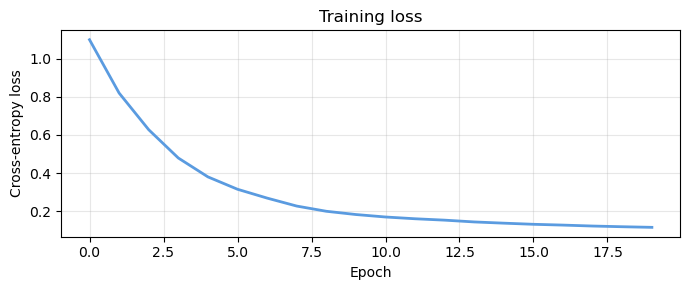

[1.0987919092178344, 0.819215965270996, 0.6270923018455505, 0.4788642704486847, 0.3799205541610718, 0.3150486290454865, 0.2687839537858963, 0.22703781425952912, 0.1997065156698227, 0.1826237380504608]
[0.09611787050962448, 0.09645723849534989, 0.09664782881736755, 0.09586022198200225, 0.09537186622619628, 0.09684080481529236, 0.09521899670362473, 0.09466219544410706, 0.09622052460908889, 0.09548272639513015]


In [84]:
plot_loss(history[:20])
print(history[:10])
print(history[-10:])

--------
# Validation

In [18]:
model = TinyTransformer(
    vocab_size=VOCAB_SIZE,
    embed_dim=32,
    n_heads=4,
    n_layers=3,
    seq_len=12,
).to(device)

checkpoint = torch.load("checkpoints\ckpt_epoch100.pt", weights_only=True)
model.load_state_dict(checkpoint["model_state"])
loss = checkpoint["loss"]

In [19]:
model_untrained = TinyTransformer(
    vocab_size=VOCAB_SIZE,
    embed_dim=32,
    n_heads=4,
    n_layers=3,
    seq_len=12,
).to(device)

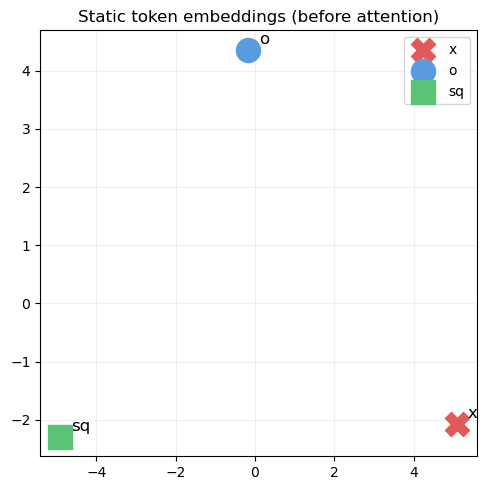

KeyError: 'x '

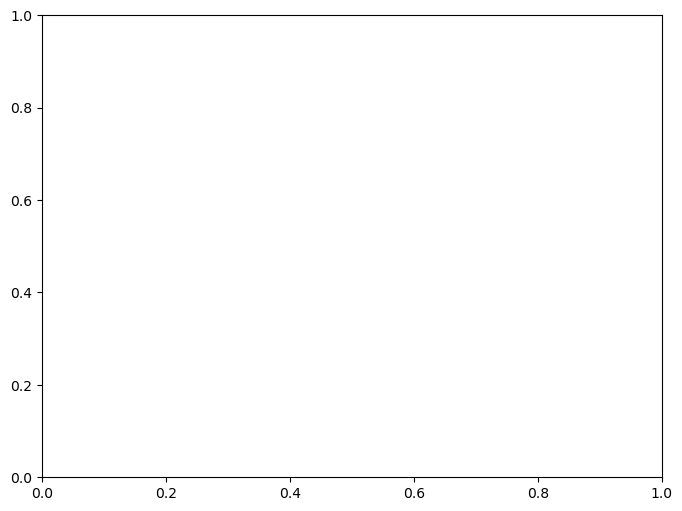

In [20]:
# plot_loss(loss)
plot_static_embeddings(model)
plot_contextual_embeddings(model)
plot_attention_maps(model)

In [21]:
# ── Generation demo ──────────────────────────────────────────────────────
print("\n── Pattern Completion ──────────────────────────────────────")
print("pattern → completion")
prompts = {
        "x  x  x  "*4      :       [X ,X ,X ]*4,
        "x  o  sq "*4      :       [X ,O ,SQ]*4,
        "x  o  "*6      :       [X ,O]*6,
        "sq o  x  "*4      :       [SQ,O ,X ]*4,
}
for desc, prompt in prompts.items():
    result = generate(model, prompt, n_new=6)
    result = result[12:]
    readable = " ".join(IDX2TOK[t] for t in result)
    print(f"{desc:45s} → {readable}")


── Pattern Completion ──────────────────────────────────────
pattern → completion
x  x  x  x  x  x  x  x  x  x  x  x            → x  x  x  x  x  x 
x  o  sq x  o  sq x  o  sq x  o  sq           → x  o  sq x  o  sq
x  o  x  o  x  o  x  o  x  o  x  o            → x  o  x  o  x  o 
sq o  x  sq o  x  sq o  x  sq o  x            → o  sq x  o  sq x 


In [22]:
def nums_to_tokens(nums):
    mapping = {0: "X", 1: "O", 2: "SQ"}
    return " ".join(mapping[n] for n in nums)

# Example
data = [0, 1, 2, 0, 0]
result = nums_to_tokens(data)
print(result)  # X O SQ X X

X O SQ X X


In [23]:
patterns = {
    "repeat-x" : [X,X,X]*4,
            "repeat-o" : [O,O,O]*4,
            "alternate-x/o" : [X,O]*6,
            "cycle" : [SQ,X,O]*4}

trained   = []
untrained = []
description  = []
for pattern,prompt in patterns.items():
    trained.append(return_probs(model,prompt))
    untrained.append(return_probs(model_untrained,prompt))
    description.append(nums_to_tokens(prompt))

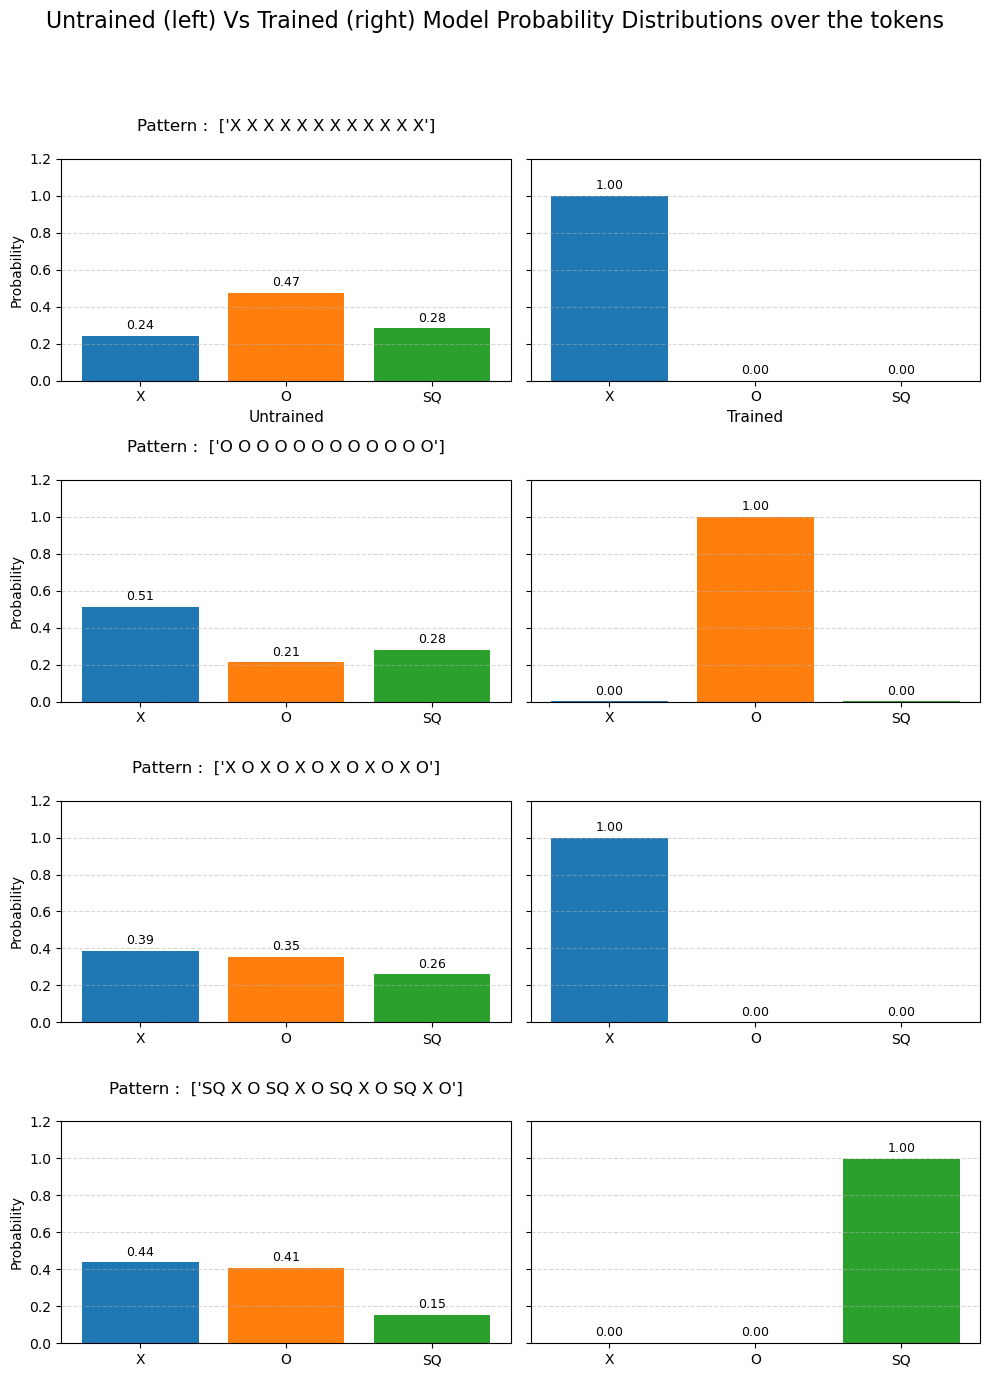

In [24]:
import matplotlib.pyplot as plt

tokens = ["X", "O", "SQ"]

# Assign a color per token (consistent everywhere)
colors = {
    "X": "tab:blue",
    "O": "tab:orange",
    "SQ": "tab:green"
}

fig, axes = plt.subplots(4, 2, figsize=(10, 14), sharey='row')

for i in range(4):
    ax_left = axes[i, 0]
    ax_right = axes[i, 1]

    probs_u = untrained[i]
    probs_t = trained[i]

    # Untrained (left)
    bars_u = ax_left.bar(tokens, probs_u,color=[colors[t] for t in tokens])
    for bar, p in zip(bars_u, probs_u):
        ax_left.text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + 0.02,
                     f"{p:.2f}",
                     ha='center', va='bottom', fontsize=9)

    ax_left.set_ylim(0, 1.2)
    ax_left.set_ylabel("Probability")
    ax_left.set_title(f"Pattern :  {[description[i]]}", fontsize=12, pad=20)
    ax_left.grid(axis='y', linestyle='--', alpha=0.5)

    # Trained (right)
    bars_t = ax_right.bar(tokens, probs_t,color=[colors[t] for t in tokens])
    for bar, p in zip(bars_t, probs_t):
        ax_right.text(bar.get_x() + bar.get_width()/2,
                      bar.get_height() + 0.02,
                      f"{p:.2f}",
                      ha='center', va='bottom', fontsize=9)

    ax_right.set_title("")  # remove per-plot title
    ax_right.grid(axis='y', linestyle='--', alpha=0.5)

    # Column headers only on first row
    if i == 0:
        ax_left.set_xlabel("Untrained", fontsize=11)
        ax_right.set_xlabel("Trained", fontsize=11)


fig.suptitle("Untrained (left) Vs Trained (right) Model Probability Distributions over the tokens", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.94])  # leave space for legend

plt.show()

In [25]:
X_PATTERN_SEQS = {
    "repeat-x" : [X,X,X]*4,
    "alternate-x/o" : [O,X]*6,
    "alternate-x/sq" : [SQ,X]*6,
    "cycle-x-last" : [O,SQ,X]*4
}

O_PATTERN_SEQS = {
    "repeat-o" : [O,O,O]*4,
    "alternate-o/x" : [X,O]*6,
    "alternate-o/sq" : [SQ,O]*6,
    "cycle-o-last" : [SQ,X,O]*4
}

SQ_PATTERN_SEQS = {
    "repeat-sq" : [SQ,SQ,SQ]*4,
    "alternate-sq/x" : [X,SQ]*6,
    "alternate-sq/o" : [O,SQ]*6,
    "cycle-sq-last" : [X,O,SQ]*4
}

# let's concatenate all dicts
ALL_PATTERN_SEQS = (X_PATTERN_SEQS | O_PATTERN_SEQS | SQ_PATTERN_SEQS)
 
PATTERN_COLORS = {
    "repeat-X":      "#E05A5A",
    "cycle-3":       "#5A9BE0",
    "alternate":     "#5AC476",
    "reverse-cycle": "#E0A85A",
}

# Gather all hidden states
pattern_layers = {}
with torch.no_grad():
    for name, seq in ALL_PATTERN_SEQS.items():
        t = torch.tensor(seq, dtype=torch.long).unsqueeze(0)
        layers = model.get_all_layer_outputs(t)   # list of (1,T,D)
        pattern_layers[name] = [l[0] for l in layers]   # list of (T,D)

n_layers = len(list(pattern_layers.values()))   # should be 3 (emb + 2 layers)


In [26]:
# ── Fit PCA on ALL vectors across all patterns and all layers ─────────────────
all_vecs = np.concatenate([
    np.concatenate(layers, axis=0)
    for layers in pattern_layers.values()
], axis=0)
 
pca = PCA(n_components=3)
pca.fit(all_vecs)
 
def proj(vecs):
    """Project (T, D) → (T, 3)"""
    return pca.transform(vecs)

In [27]:
static_vecs = model.token_emb.weight[:3].detach().cpu().numpy()   # (3, D)
static_3d   = pca.transform(static_vecs)  
print(static_3d)

[[-2.2398798  3.2148547 -3.2820613]
 [-1.473021  -1.7316301  1.3890243]
 [ 3.3337781 -1.6507084  2.936701 ]]


In [28]:
x_pattern_layers = {}
with torch.no_grad():
    for name, seq in X_PATTERN_SEQS.items():
        t = torch.tensor(seq, dtype=torch.long).unsqueeze(0)
        h = model.get_all_layer_last_emb(t)   # list of (1,T,D)
        x_pattern_layers[name] = h   # list of (T,D)


o_pattern_layers = {}
with torch.no_grad():
    for name, seq in O_PATTERN_SEQS.items():
        t = torch.tensor(seq, dtype=torch.long).unsqueeze(0)
        h = model.get_all_layer_last_emb(t)   # list of (1,T,D)
        o_pattern_layers[name] = h   # list of (T,D)


sq_pattern_layers = {}
with torch.no_grad():
    for name, seq in SQ_PATTERN_SEQS.items():
        t = torch.tensor(seq, dtype=torch.long).unsqueeze(0)
        h = model.get_all_layer_last_emb(t)   # list of (1,T,D)
        sq_pattern_layers[name] = h   # list of (T,D)

x_pattern_layers_3D = [proj(np.stack(patt)) for _, patt in x_pattern_layers.items()]
o_pattern_layers_3D = [proj(np.stack(patt)) for _, patt in o_pattern_layers.items()]
sq_pattern_layers_3D = [proj(np.stack(patt)) for _, patt in sq_pattern_layers.items()]

In [29]:
import numpy as np
import plotly.graph_objects as go

symbols = {"X" : "x",
           "O" : "circle",
           "SQ": "square"}


# Static embeddings for tokens X, O, SQ (already 3D)
static_embeddings = static_3d
contexts = [x_pattern_layers_3D,o_pattern_layers_3D,sq_pattern_layers_3D]

context_labels = ["repeat", "alternate1", "alternate2", "cycle"]

pattern_colors = {
    "repeat": "cyan",
    "alternate1": "violet",
    "alternate2": "lawngreen",
    "cycle": "lightcoral"
}

colors = ["cyan", "violet", "lawngreen"]

# --- Plotly figure ---
fig = go.Figure()


# Plot static token embeddings (anchors)
for i, token in enumerate(tokens):
    fig.add_trace(go.Scatter3d(
        x=[static_embeddings[i, 0]],
        y=[static_embeddings[i, 1]],
        z=[static_embeddings[i, 2]],
        mode='markers+text',
        marker=dict(size=8, symbol=symbols[token]),
        text=[token],
        textposition="top center",
        name=f"Layer-0 (before attention) Embedding of {token}"
    ))


for i, context in enumerate(contexts): 
    for ctx, label in zip(context, context_labels):
        x, y, z = ctx[:, 0], ctx[:, 1], ctx[:, 2]
        color = pattern_colors[label]
        
        # line + markers
        fig.add_trace(go.Scatter3d(
            x=x, y=y, z=z,
            mode='lines+markers',
            marker=dict(size=4, color=colors[i]),
            line=dict(width=4, color=colors[i]),
            showlegend=False
        ))
        
        # start
        fig.add_trace(go.Scatter3d(
            x=[x[0]], y=[y[0]], z=[z[0]],
            mode='markers',
            marker=dict(size=2*i, color=color, symbol='circle'),
            showlegend=False
        ))
        

# Layout
fig.update_layout(
    title="3D Embedding Trajectories Across The Three Layers of Trnasformers for each pattern (repeat, alternate, cycle) ",
    scene=dict(
        xaxis_title="PCA 1",
        yaxis_title="PCA 2",
        zaxis_title="PCA 3",
    ),
    legend=dict(x=0.02, y=0.98),
    margin=dict(l=0, r=0, b=0, t=40)
)

fig.show()

C:\Users\kajou\AppData\Roaming\Python\Python311\site-packages\kaleido\_sync_server.py:11: UserWarning:




This means that static image generation (e.g. `fig.write_image()`) will not work.

Please upgrade Plotly to version 6.1.1 or greater, or downgrade Kaleido to version 0.2.1.




This forshows exactly how LLMs can solve the problem of homonyms (names with sam spelling but may have multiple meanings), each one get pushed to its appropriate cluster thorugh attention layers.


In [30]:
import numpy as np
import imageio


frames = []
n_frames = 60  # smoothness of rotation
images = []


for t in np.linspace(0, 2*np.pi, n_frames):
    camera = dict(
        eye=dict(
            x=2*np.cos(t),
            y=2*np.sin(t),
            z=0.8  # slight tilt
        )
    )

    frames.append(go.Frame(layout=dict(scene_camera=camera)))


fig.frames = frames

fig.update_layout(
    updatemenus=[dict(
        type="buttons",
        showactive=False,
        buttons=[
            dict(label="Rotate",
                 method="animate",
                 args=[None, {
                     "frame": {"duration": 50, "redraw": True},
                     "fromcurrent": True,
                     "loop": True
                 }])
        ]
    )]
)

In [31]:
pca2d = PCA(n_components=2)
pca2d.fit(all_vecs)
 
def proj2d(vecs):
    """Project (T, D) → (T, 3)"""
    return pca2d.transform(vecs)

static_2d   = pca2d.transform(static_vecs)  
print(static_2d)

x_pattern_layers_2D = [proj2d(np.stack(patt)) for _, patt in x_pattern_layers.items()]


[[-2.2398775  3.2148569]
 [-1.4730209 -1.731631 ]
 [ 3.3337758 -1.6507106]]


In [32]:
print(x_pattern_layers_2D[3])

[[-2.2398775  3.2148569]
 [-2.3028212  3.4495387]
 [-2.6763098  4.0672007]
 [-1.6107724  4.506616 ]]


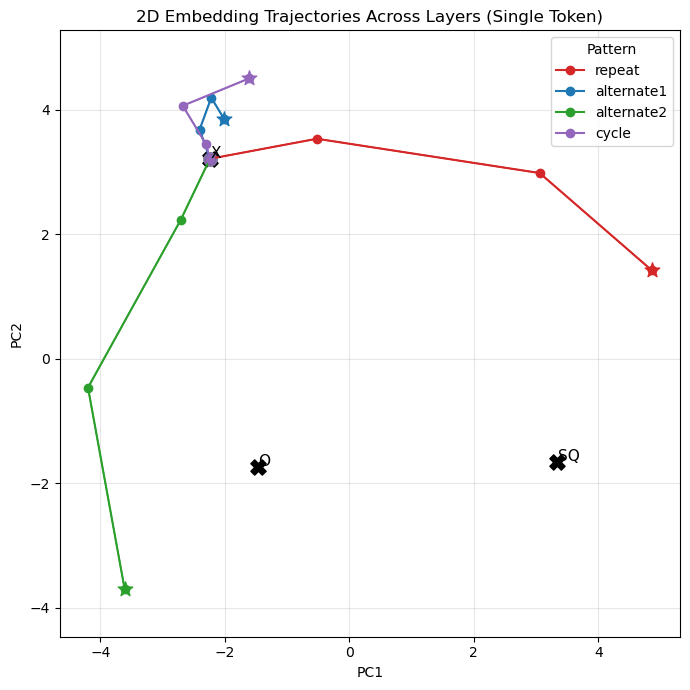

In [33]:

# --- Colors per pattern ---
pattern_colors = {
    "repeat": "tab:red",
    "alternate1": "tab:blue",
    "alternate2": "tab:green",
    "cycle": "tab:purple"
}

# --- Plot ---
plt.figure(figsize=(7, 7))

# Plot static embeddings (anchors)
for i, token in enumerate(tokens):
    x, y = static_2d[i]
    plt.scatter(x, y, s=120, marker='X', color='black')
    plt.text(x + 0.01, y + 0.01, token, fontsize=11)

# Plot trajectories
for name, traj in zip(context_labels,x_pattern_layers_2D):
    x, y = traj[:, 0], traj[:, 1]
    color = pattern_colors[name]

    # line
    plt.plot(x, y, marker='o', color=color, label=name)

    # arrows (direction)
    for i in range(len(x) - 1):
        plt.arrow(x[i], y[i],
                  x[i+1] - x[i],
                  y[i+1] - y[i],
                  head_width=0.02,
                  length_includes_head=True,
                  color=color,
                  alpha=0.6)

    # start / end markers
    plt.scatter(x[0], y[0], color=color, s=80, marker='o')   # start
    plt.scatter(x[-1], y[-1], color=color, s=120, marker='*') # end

# Styling
plt.title("2D Embedding Trajectories Across Layers (Single Token)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(title="Pattern")
plt.grid(alpha=0.3)

plt.axis('equal')
plt.tight_layout()

plt.show()

In [41]:
np.linalg.norm([1,1])

1.4142135623730951

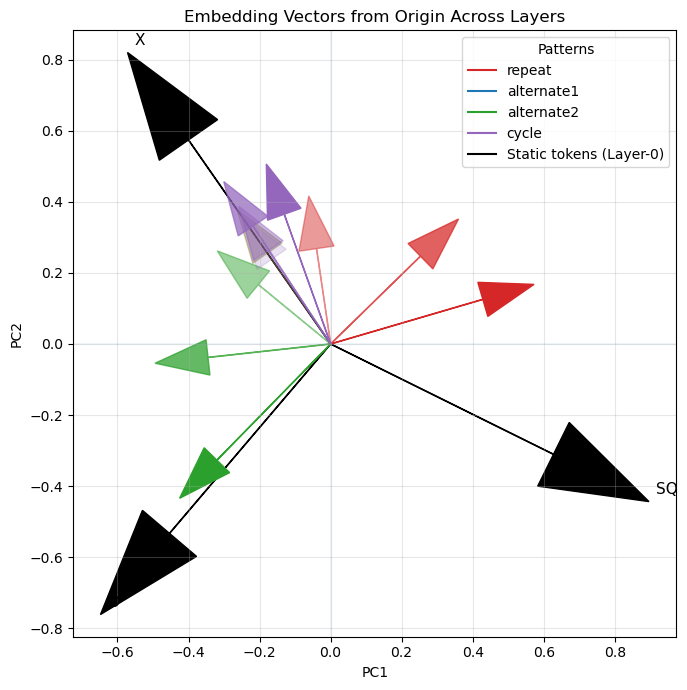

In [39]:
plt.figure(figsize=(7, 7))

# Plot static embeddings as reference arrows
for i, token in enumerate(tokens):
    u = static_2d[i]
    x, y = u/np.linalg.norm(u)
    plt.arrow(0, 0, x, y,
              head_width=0.2,
              length_includes_head=True,
              color='black',
              alpha=1.)
    plt.text(x + 0.02, y + 0.02, token, fontsize=11)

# Plot arrows for each pattern and layer
for name, traj in zip(context_labels,x_pattern_layers_2D):
    traj = traj/np.linalg.norm(traj)
    if name =="alternate1" : continue
    color = pattern_colors[name]
    n = len(traj)

    for i, (x, y) in enumerate(traj):
        alpha = 0.2 + 0.8 * (i / (n - 1))  # fade-in over layers
        
        plt.arrow(0, 0, x, y,
                  head_width=0.1,
                  length_includes_head=True,
                  color=color,
                  alpha=alpha)

# Styling
plt.title("Embedding Vectors from Origin Across Layers")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(alpha=0.3)

plt.axhline(0, linewidth=0.1)
plt.axvline(0, linewidth=0.1)

plt.axis('equal')
plt.tight_layout()

# Custom legend (since arrows don't auto-legend well)
for name, color in pattern_colors.items():
    plt.plot([], [], color=color, label=name)
plt.plot([], [], color='black', label='Static tokens (Layer-0)')

plt.legend(title="Patterns")

plt.show()

In [35]:
def plot_attention_maps(model):
    model.eval()

    test_seqs = {
        "repeat-x":      pattern_repeat(X)[:-1],
        "cycle-3":       pattern_cycle3()[:-1],
        "alternate" :    pattern_alternate1()[:-1]
            }

    fig, axes = plt.subplots(1, 4, figsize=(16, 4))

    with torch.no_grad():
        for ax, (name, seq) in zip(axes, test_seqs.items()):

            t = torch.tensor(seq, dtype=torch.long).unsqueeze(0).to(device)
            # unsqueeze(0) adds the batch dimension: (T,) → (1, T)

            T = len(seq)

            # ── Build inputs manually so we can call self_attn directly ──────
            # Instead of relying on the hook (which depends on PyTorch version),
            # we replicate exactly what TransformerEncoderLayer does internally,
            # but call self_attn ourselves so we control need_weights.

            pos = torch.arange(T).unsqueeze(0).to(device)
            emb = model.token_emb(t) + model.pos_emb(pos)
            # emb shape: (1, T, D) — batch_first=True

            # LayerNorm before self-attention (Pre-LN architecture in PyTorch)
            layer   = model.transformer.layers[1]
            normed  = layer.norm1(emb)
            # norm1 is the first LayerNorm in the encoder layer

            # ── Call self_attn directly with need_weights=True ────────────────
            # self_attn expects (T, B, D) when batch_first=False internally,
            # but since batch_first=True was set at construction, we pass (B,T,D)
            # and PyTorch handles the transpose internally.
            #
            # Returns: (attn_output, attn_weights)
            #   attn_output  : (B, T, D)
            #   attn_weights : (B, T, T) — averaged across heads by default
            attn_output, attn_weights = layer.self_attn(
                normed, normed, normed,           # query, key, value = same tensor (self-attention)
                attn_mask=model._causal_mask(T).to(device),
                need_weights=True,
                average_attn_weights=False,       # keep per-head: (B, n_heads, T, T)
            )

            # attn_weights shape: (1, n_heads, T, T)
            # take head 0 of batch 0 → (T, T)
            w = attn_weights[0, 0].cpu().numpy()

            # ── Plot ──────────────────────────────────────────────────────────
            tok_labels = [IDX2TOK[i] for i in seq]

            im = ax.imshow(w, cmap="Blues", vmin=0, vmax=1)

            ax.set_xticks(range(T))
            ax.set_xticklabels(tok_labels, fontsize=7, rotation=45)
            # x-axis = keys  (what is being attended TO)

            ax.set_yticks(range(T))
            ax.set_yticklabels(tok_labels, fontsize=7)
            # y-axis = queries (who is doing the attending)

            ax.set_xlabel("Key (attended to)", fontsize=8)
            ax.set_ylabel("Query (attending)", fontsize=8)
            ax.set_title(name, fontsize=10)

            plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    plt.suptitle(
        "Attention maps — head 0, layer 0\n"
        "Row i = how much token i attends to each other token",
        fontsize=11, y=1.04
    )
    plt.tight_layout()
    plt.savefig("attention_maps.png", dpi=130, bbox_inches="tight")
    plt.show()
    print("Saved: attention_maps.png")

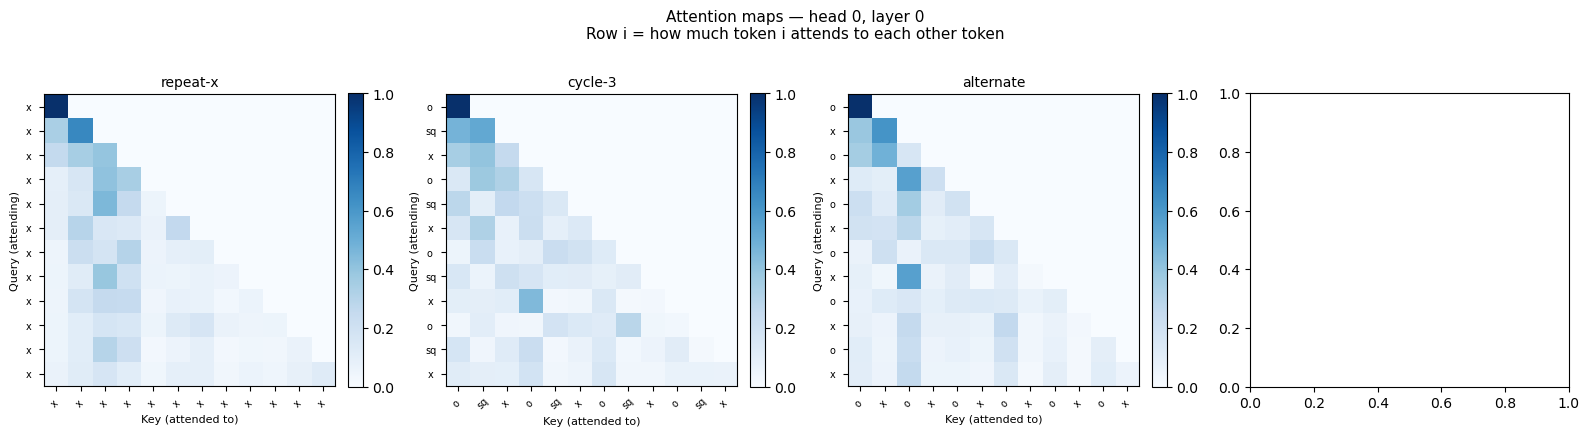

Saved: attention_maps.png


In [36]:
plot_attention_maps(model)

In [37]:
def plot_attention_maps_v2(model):
    """
    Three panels per pattern:
      Left   — raw attention (layer 1, mean across heads)
      Middle — value-weighted attention (layer 1)
      Right  — attention rollout across both layers

    This is what researchers actually use.
    """
    model.eval()

    test_seqs = {
        "repeat-x":      pattern_repeat(X)[:-1],
        "cycle-3":       pattern_cycle3()[:-1],
        "alternate":     pattern_alternate1()[:-1]
    }

    n_patterns = len(test_seqs)
    fig, axes  = plt.subplots(n_patterns, 3,
                              figsize=(13, 3.5 * n_patterns))
    fig.suptitle(
        "Attention analysis — all methods compared\n"
        "Left: raw attn | Middle: value-weighted | Right: rollout",
        fontsize=12, y=1.01
    )

    def get_attn_and_values(layer, emb, causal_mask):
        """
        Run one TransformerEncoderLayer's self-attention manually.
        Returns:
            attn_weights : (n_heads, T, T)  — raw softmax weights
            V            : (n_heads, T, head_dim) — value vectors
        """
        normed = layer.norm1(emb)
        B, T, D = normed.shape
        n_heads  = layer.self_attn.num_heads
        head_dim = D // n_heads

        # Extract Q K V projection weights from the in_proj_weight
        # PyTorch packs Q, K, V into one matrix of shape (3D, D)
        W = layer.self_attn.in_proj_weight   # (3D, D)
        b = layer.self_attn.in_proj_bias     # (3D,)
        Wq, Wk, Wv = W[:D], W[D:2*D], W[2*D:]
        bq, bk, bv = b[:D], b[D:2*D], b[2*D:]

        # Project: (B, T, D)
        Q = normed @ Wq.T + bq
        K = normed @ Wk.T + bk
        V = normed @ Wv.T + bv

        # Reshape to (B, n_heads, T, head_dim)
        def split_heads(x):
            return x.view(B, T, n_heads, head_dim).transpose(1, 2)

        Q = split_heads(Q)   # (1, n_heads, T, head_dim)
        K = split_heads(K)
        V = split_heads(V)

        # Scaled dot-product attention
        scale  = head_dim ** -0.5
        scores = Q @ K.transpose(-2, -1) * scale   # (1, n_heads, T, T)

        # Apply causal mask
        scores = scores.masked_fill(
            causal_mask.unsqueeze(0).unsqueeze(0), float("-inf")
        )
        attn = torch.softmax(scores, dim=-1)
        # Replace nan (rows that were all -inf, i.e. future-only positions)
        attn = torch.nan_to_num(attn, nan=0.0)

        return (
            attn[0].detach().cpu(),    # (n_heads, T, T)
            V[0].detach().cpu(),       # (n_heads, T, head_dim)
        )

    def attention_rollout(attn_list):
        """
        attn_list: list of (n_heads, T, T) tensors, one per layer.
        Returns rollout matrix (T, T).

        Algorithm (Abnar & Zuidema 2020):
          1. Average across heads
          2. Add identity (residual connection)
          3. Renormalize rows
          4. Multiply across layers
        """
        rollout = None
        for attn in attn_list:
            # Average across heads → (T, T)
            A = attn.mean(dim=0).numpy()
            # Add residual and renormalize
            A = A + np.eye(A.shape[0])
            A = A / A.sum(axis=1, keepdims=True)
            rollout = A if rollout is None else A @ rollout
        return rollout   # (T, T)

    def value_weighted(attn, V):
        """
        attn : (n_heads, T, T)
        V    : (n_heads, T, head_dim)
        Returns (T, T) — attention weighted by value norms.
        """
        # Value norms per head per token: (n_heads, T)
        v_norms = V.norm(dim=-1)
        # Weight each attention row by value norms: (n_heads, T, T)
        weighted = attn * v_norms.unsqueeze(-2)
        # Average across heads and normalize rows → (T, T)
        w = weighted.mean(dim=0).numpy()
        row_sums = w.sum(axis=1, keepdims=True)
        row_sums = np.where(row_sums == 0, 1, row_sums)
        return w / row_sums

    def draw_heatmap(ax, matrix, tok_labels, title, cmap="Blues"):
        T   = len(tok_labels)
        im  = ax.imshow(matrix, cmap=cmap, vmin=0,
                        vmax=matrix.max() if matrix.max() > 0 else 1,
                        aspect="auto")
        ax.set_xticks(range(T))
        ax.set_xticklabels(tok_labels, fontsize=7, rotation=45, ha="right")
        ax.set_yticks(range(T))
        ax.set_yticklabels(tok_labels, fontsize=7)
        ax.set_xlabel("Key →", fontsize=7)
        ax.set_ylabel("← Query", fontsize=7)
        ax.set_title(title, fontsize=9, pad=4)
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    with torch.no_grad():
        for row, (pname, seq) in enumerate(test_seqs.items()):
            t    = torch.tensor(seq, dtype=torch.long).unsqueeze(0).to(device)
            T    = len(seq)
            mask = model._causal_mask(T).to(device)
            pos  = torch.arange(T).unsqueeze(0).to(device)
            tok_labels = [IDX2TOK[i] for i in seq]

            # Build embedding
            emb = model.token_emb(t) + model.pos_emb(pos)

            # Collect attention + values for every layer
            attn_per_layer = []
            h = emb
            for layer in model.transformer.layers:
                attn, V = get_attn_and_values(layer, h, mask)
                attn_per_layer.append(attn)
                # Advance h through the full layer for next iteration
                h = layer(h, src_mask=mask)

            # ── Use the LAST layer for raw + value-weighted ───────────────────
            last_attn = attn_per_layer[-1]   # (n_heads, T, T)
            last_V    = V                    # already from last layer

            # Raw: mean across heads
            raw_mean = last_attn.mean(dim=0).numpy()

            # Value-weighted
            vw = value_weighted(last_attn, last_V)

            # Rollout across all layers
            rollout = attention_rollout(attn_per_layer)

            # ── Draw the 3 panels for this pattern ───────────────────────────
            ax_raw, ax_vw, ax_roll = axes[row]

            draw_heatmap(ax_raw,  raw_mean,
                         tok_labels,
                         f"{pname}\nRaw attn (last layer, mean heads)")
            draw_heatmap(ax_vw,   vw,
                         tok_labels,
                         f"{pname}\nValue-weighted attn")
            draw_heatmap(ax_roll, rollout,
                         tok_labels,
                         f"{pname}\nAttention rollout (all layers)",
                         cmap="Purples")

    plt.tight_layout()
    plt.savefig("attention_maps_v2.png", dpi=130, bbox_inches="tight")
    plt.show()
    print("Saved: attention_maps_v2.png")

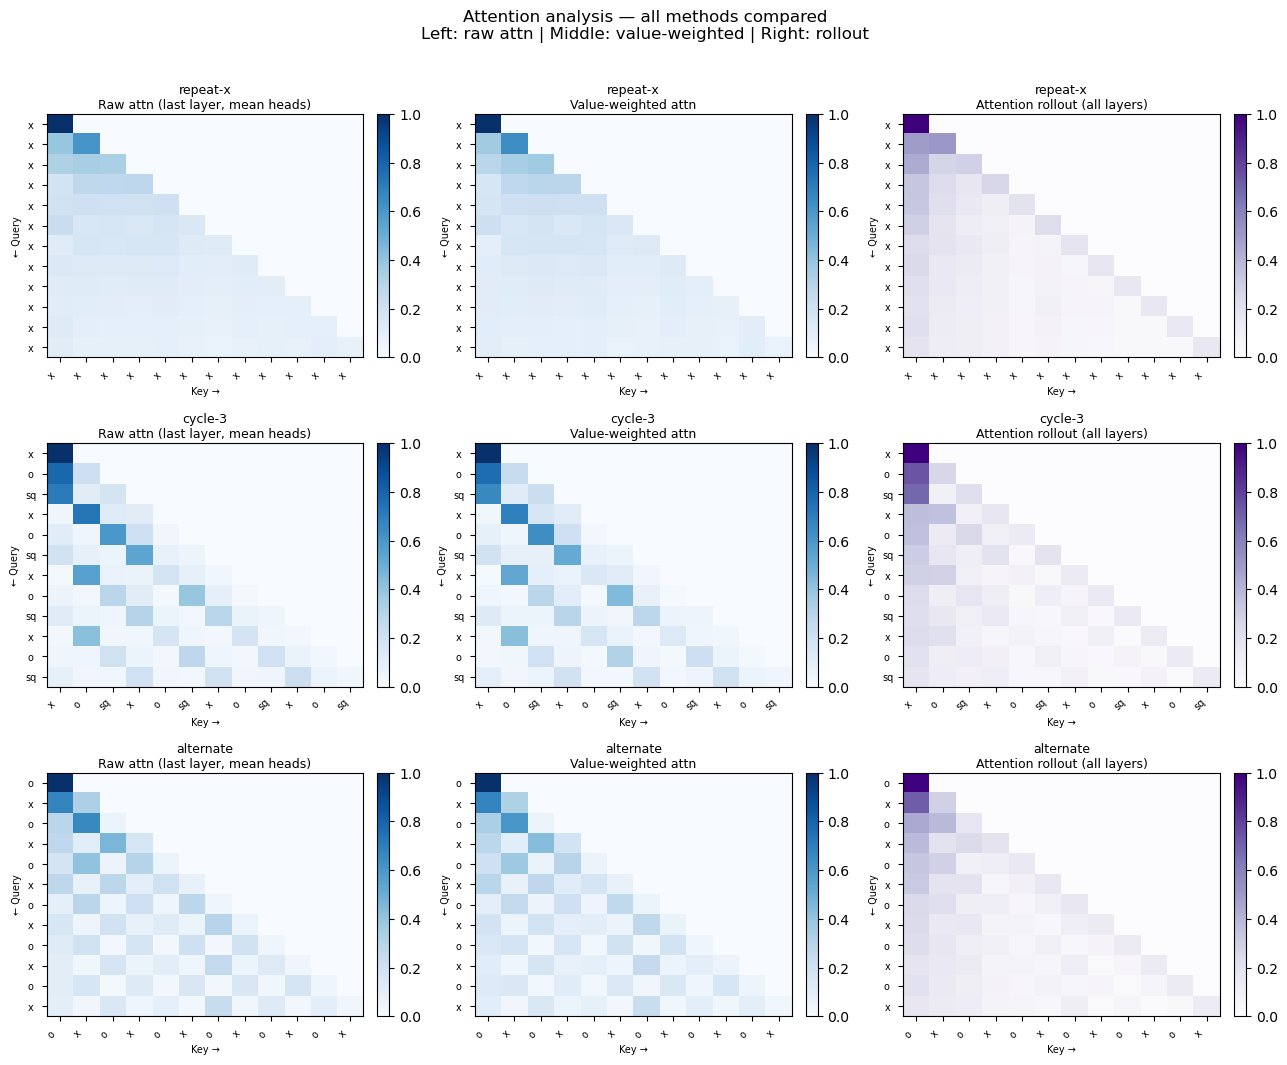

Saved: attention_maps_v2.png


In [38]:
plot_attention_maps_v2(model)

# Exercise : 

Now inspiring from the above, learn an Encoder-transformer ( like Bert) to perform calssification, where it must predict which patter we are in : repetiion (xxxxx), alterneation (xoxoxoxox), or cycling (xoqsxosq) 